# CatBoost2 — Entrenamiento Local (CPU)

**Proyecto:** MECMT07 — Home Credit Default Risk  
**Versión:** v2 — 5-fold CV + variables categóricas nativas  
**Plataforma:** Local (CPU)  
**Dataset fuente:** `data/processed/features_train_cat.parquet`

**Diferencias respecto a catboost2-cloud-train.ipynb:**
- Sin GPU: `task_type='CPU'` siempre
- Bootstrap type incluye `'MVS'` (disponible solo en CPU)
- Rutas locales (`../../data/processed/` y `./`)
- Log completo guardado en `catboost2_local_train.log`

**Estrategia:**
- CatBoost maneja NaN y categóricas nativamente
- `auto_class_weights='Balanced'` para desbalance de clases
- Optuna 20 trials: objetivo = CV AUC − 0.5 · gap (penaliza overfitting)
- `catboost.cv()` con 5-fold estratificado y early stopping

**Outputs en `cloud/catboost2/`:**
- `catboost2_local_best.cbm` — modelo final (formato binario CatBoost)
- `catboost2_local_metadata.json` — hiperparámetros, AUC, feature_cols, cat_cols
- `catboost2_local_train.log` — log completo del entrenamiento
- `optuna_trials.csv` — historial de todos los trials

In [1]:
!pip install optuna catboost --quiet
print('Dependencias listas.')

Dependencias listas.


In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings('ignore')

import catboost
from catboost import CatBoostClassifier, Pool
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

print(f'CatBoost version : {catboost.__version__}')
print(f'Optuna  version  : {optuna.__version__}')
print('Imports OK')

CatBoost version : 1.2.10
Optuna  version  : 4.7.0
Imports OK


In [3]:
import logging
import sys

MODEL_DIR = Path('.')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

LOG_PATH = MODEL_DIR / 'catboost2_local_train.log'

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s │ %(message)s',
    datefmt='%H:%M:%S',
    handlers=[
        logging.FileHandler(LOG_PATH, mode='w', encoding='utf-8'),
        logging.StreamHandler(sys.stdout),
    ]
)
_logger = logging.getLogger('catboost2')

def log(msg=''):
    """Imprime en pantalla Y escribe en el .log."""
    _logger.info(str(msg))

log(f'Log iniciado → {LOG_PATH.resolve()}')
log('Logger configurado OK')

00:23:08 │ Log iniciado → /home/jupyter/catboost2_local_train.log
00:23:08 │ Logger configurado OK


In [4]:
DATA_DIR  = Path('.')

USE_GPU    = False  # CPU siempre (versión local)
N_TRIALS   = 20
N_FOLDS    = 5
EARLY_STOP = 50
MAX_ITER   = 1000
SEED       = 42

matplotlib.rcParams.update({
    'figure.figsize': (9, 6), 'font.size': 12,
    'axes.spines.top': False, 'axes.spines.right': False
})

log('=' * 60)
log('CONFIGURACIÓN')
log(f'  DATA_DIR   : {DATA_DIR}')
log(f'  MODEL_DIR  : {MODEL_DIR.resolve()}')
log(f'  N_TRIALS   : {N_TRIALS}')
log(f'  N_FOLDS    : {N_FOLDS}  (CV 5-fold)')
log(f'  EARLY_STOP : {EARLY_STOP}')
log(f'  MAX_ITER   : {MAX_ITER}')
log(f'  SEED       : {SEED}')
log(f'  GPU        : {USE_GPU}  (CPU mode)')
log('=' * 60)

00:23:08 │ ============================================================
00:23:08 │ CONFIGURACIÓN
00:23:08 │   DATA_DIR   : .
00:23:08 │   MODEL_DIR  : /home/jupyter
00:23:08 │   N_TRIALS   : 20
00:23:08 │   N_FOLDS    : 5  (CV 5-fold)
00:23:08 │   EARLY_STOP : 50
00:23:08 │   MAX_ITER   : 1000
00:23:08 │   SEED       : 42
00:23:08 │   GPU        : False  (CPU mode)
00:23:08 │ ============================================================


In [5]:
log('Cargando datos...')
df      = pd.read_parquet('features_train_cat.parquet')
df_test = pd.read_parquet('features_test_cat.parquet')

feature_cols = [c for c in df.columns if c not in ('SK_ID_CURR', 'TARGET')]

# Detectar columnas categóricas (object dtype) → CatBoost las procesa nativamente
cat_cols         = [c for c in feature_cols if df[c].dtype == 'object']
cat_features_idx = [feature_cols.index(c) for c in cat_cols]

# X como DataFrame con copy (evita SettingWithCopyWarning)
X           = df[feature_cols].copy()
y           = df['TARGET'].values
X_test      = df_test[feature_cols].copy()
sk_ids_test = df_test['SK_ID_CURR'].values

# CatBoost Pool no acepta None/NaN en columnas categóricas →
# rellenar con 'missing' (string explícito); numéricas las maneja solo
nan_cat_train = X[cat_cols].isna().sum().sum()
nan_cat_test  = X_test[cat_cols].isna().sum().sum()
if nan_cat_train > 0 or nan_cat_test > 0:
    log(f'  NaN en cat cols (train): {nan_cat_train} → rellenando con "missing"')
    log(f'  NaN en cat cols (test) : {nan_cat_test} → rellenando con "missing"')
X[cat_cols]      = X[cat_cols].fillna('missing')
X_test[cat_cols] = X_test[cat_cols].fillna('missing')

n_neg, n_pos = (y == 0).sum(), (y == 1).sum()

# Pool para catboost.cv()
pool = Pool(X, label=y, cat_features=cat_features_idx, feature_names=feature_cols)

log(f'  Train shape        : {X.shape}')
log(f'  Test  shape        : {X_test.shape}')
log(f'  Features totales   : {len(feature_cols)}')
log(f'  Features numéricas : {len(feature_cols) - len(cat_cols)}')
log(f'  Features categóric.: {len(cat_cols)}  → {cat_cols}')
log(f'  TARGET=0 (paga)    : {n_neg:,}  ({100*n_neg/(n_neg+n_pos):.1f}%)')
log(f'  TARGET=1 (default) : {n_pos:,}  ({100*n_pos/(n_neg+n_pos):.1f}%)')
log('Pool creado OK')

00:23:08 │ Cargando datos...
00:23:09 │   NaN en cat cols (train): 96391 → rellenando con "missing"
00:23:09 │   NaN en cat cols (test) : 15605 → rellenando con "missing"
00:23:09 │   Train shape        : (307511, 36)
00:23:09 │   Test  shape        : (48744, 36)
00:23:09 │   Features totales   : 36
00:23:09 │   Features numéricas : 30
00:23:09 │   Features categóric.: 6  → ['NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
00:23:09 │   TARGET=0 (paga)    : 282,686  (91.9%)
00:23:09 │   TARGET=1 (default) : 24,825  (8.1%)
00:23:09 │ Pool creado OK


In [6]:
def compute_metrics(y_true, y_prob, threshold=0.5, label='Model'):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    auc  = roc_auc_score(y_true, y_prob)
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return dict(Model=label, AUC=round(auc,4),
                N=len(y_true), P=int(y_pred.sum()),
                TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
                Recall=round(rec,4), Precision=round(prec,4), F1=round(f1,4))

log('Funciones auxiliares definidas.')

00:23:09 │ Funciones auxiliares definidas.


## 1. Optuna — Búsqueda de Hiperparámetros

**Función objetivo** con `catboost.cv()` + 5-fold estratificado:
$$\text{objetivo} = \text{AUC}_{\text{cv}} - 0.5 \cdot \max(0,\ \text{AUC}_{\text{train}} - \text{AUC}_{\text{cv}})$$

In [7]:
best_iter_per_trial = {}

def objective(trial):
    # CPU soporta MVS además de Bayesian y Bernoulli
    bootstrap_type = trial.suggest_categorical(
        'bootstrap_type', ['Bayesian', 'Bernoulli', 'MVS']
    )

    params = dict(
        loss_function         = 'Logloss',        # requerido por catboost.cv()
        iterations            = MAX_ITER,
        learning_rate         = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        depth                 = trial.suggest_int('depth', 4, 10),
        l2_leaf_reg           = trial.suggest_float('l2_leaf_reg', 1.0, 30.0, log=True),
        bootstrap_type        = bootstrap_type,
        random_strength       = trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        auto_class_weights    = 'Balanced',
        eval_metric           = 'AUC',
        early_stopping_rounds = EARLY_STOP,
        task_type             = 'CPU',
        random_seed           = SEED,
        verbose               = False,
    )

    if bootstrap_type == 'Bayesian':
        params['bagging_temperature'] = trial.suggest_float('bagging_temperature', 0.0, 10.0)
    elif bootstrap_type in ('Bernoulli', 'MVS'):
        params['subsample'] = trial.suggest_float('subsample', 0.5, 1.0)

    # catboost.cv() — 5-fold estratificado
    cv_result = catboost.cv(
        pool,
        params,
        fold_count            = N_FOLDS,
        stratified            = True,
        early_stopping_rounds = EARLY_STOP,
        verbose               = False,
        as_pandas             = True,
    )

    best_idx  = cv_result['test-AUC-mean'].idxmax()
    cv_auc    = cv_result.loc[best_idx, 'test-AUC-mean']
    train_auc = (cv_result.loc[best_idx, 'train-AUC-mean']
             if 'train-AUC-mean' in cv_result.columns
             else cv_auc)
    n_iter    = best_idx + 1

    best_iter_per_trial[trial.number] = n_iter
    trial.set_user_attr('train_auc', train_auc)
    trial.set_user_attr('cv_auc',    cv_auc)
    trial.set_user_attr('n_iter',    n_iter)

    gap = max(0.0, train_auc - cv_auc)
    return cv_auc - 0.5 * gap

log('Función objetivo definida.')

00:23:09 │ Función objetivo definida.


In [8]:
def _optuna_callback(study, trial):
    n      = best_iter_per_trial.get(trial.number, '?')
    marker = ' ◀ best' if trial.number == study.best_trial.number else ''
    log(f'  Trial {trial.number + 1:>2}/{N_TRIALS} │ '
        f'obj={trial.value:.5f}  '
        f'iter={str(n):>4}  │  '
        f'best={study.best_value:.5f}{marker}')

log('=' * 65)
log(f'Lanzando Optuna — {N_TRIALS} trials')
log(f'CV: {N_FOLDS}-fold estratificado  |  Early stopping: {EARLY_STOP} rounds')
log(f'Cat features: {cat_cols}')
log(f'Device: CPU')
log('=' * 65)

study = optuna.create_study(
    direction = 'maximize',
    sampler   = optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(
    objective,
    n_trials          = N_TRIALS,
    n_jobs            = 1,
    show_progress_bar = False,
    callbacks         = [_optuna_callback]
)

best_n_iter = best_iter_per_trial[study.best_trial.number]

log('=' * 65)
log(f'Búsqueda finalizada.')
log(f'  Mejor CV AUC (obj penalizado) : {study.best_value:.5f}')
log(f'  CV AUC real                   : {study.best_trial.user_attrs["cv_auc"]:.5f}')
log(f'  Train AUC                     : {study.best_trial.user_attrs["train_auc"]:.5f}')
log(f'  n_iterations óptimas          : {best_n_iter}')
log(f'  Mejores hiperparámetros:')
for k, v in study.best_params.items():
    log(f'    {k:<24}: {v}')
log('=' * 65)

trial_df = study.trials_dataframe()
trial_df.to_csv('optuna_trials.csv', index=False)
log(f'\nHistorial de trials guardado → optuna_trials.csv')

00:23:09 │ =================================================================
00:23:09 │ Lanzando Optuna — 20 trials
00:23:09 │ CV: 5-fold estratificado  |  Early stopping: 50 rounds
00:23:09 │ Cat features: ['NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
00:23:09 │ Device: CPU
00:23:09 │ =================================================================
Training on fold [0/5]

bestTest = 0.7792339044
bestIteration = 554

Training on fold [1/5]

bestTest = 0.7744986221
bestIteration = 481

Training on fold [2/5]

bestTest = 0.7839149975
bestIteration = 710

Training on fold [3/5]

bestTest = 0.779733095
bestIteration = 529

Training on fold [4/5]

bestTest = 0.7757260549
bestIteration = 477

00:27:52 │   Trial  1/20 │ obj=0.77854  iter= 711  │  best=0.77854 ◀ best
Training on fold [0/5]

bestTest = 0.7625744818
bestIteration = 29

Training on fold [1/5]

bestTest = 0.7609410237
bestIteration = 35

Training on

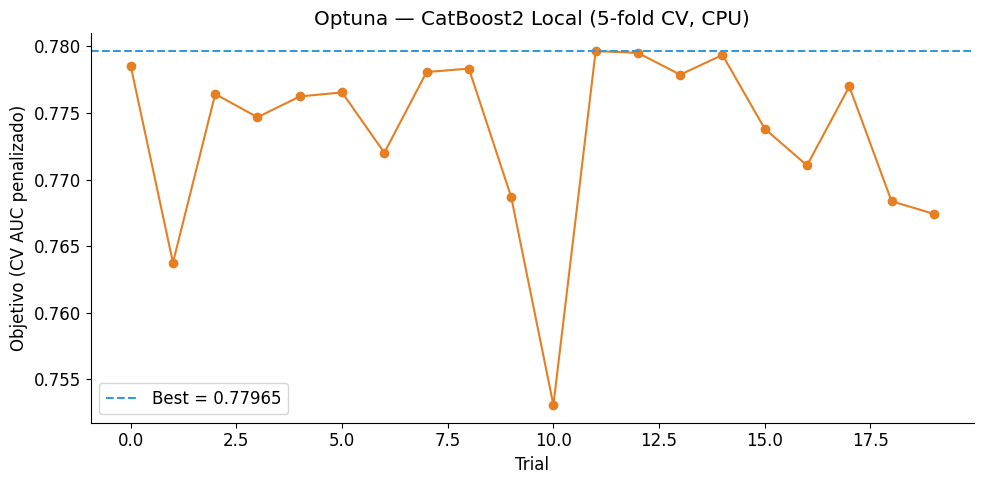

02:23:15 │ optuna_history.png guardado.


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trial_df['number'], trial_df['value'], 'o-', color='#e67e22', ms=6)
ax.axhline(study.best_value, color='#3498db', ls='--',
           label=f'Best = {study.best_value:.5f}')
ax.set_xlabel('Trial')
ax.set_ylabel('Objetivo (CV AUC penalizado)')
ax.set_title('Optuna — CatBoost2 Local (5-fold CV, CPU)')
ax.legend()
plt.tight_layout()
plt.savefig('optuna_history.png', dpi=120)
plt.show()
log('optuna_history.png guardado.')

## 2. Modelo Final — Refit en Train Completo

In [10]:
params_final = dict(
    iterations         = best_n_iter,
    auto_class_weights = 'Balanced',
    eval_metric        = 'AUC',
    task_type          = 'CPU',
    random_seed        = SEED,
    verbose            = 100,
    **study.best_params
)

log('=' * 65)
log('Entrenando modelo final en train completo...')
log(f'  Iteraciones : {best_n_iter}')
log(f'  Cat features: {cat_cols}')
log(f'  Device      : CPU')
log('=' * 65)

t0 = time.time()
model = CatBoostClassifier(**params_final)
model.fit(X, y, cat_features=cat_features_idx)
elapsed = time.time() - t0
log(f'Entrenamiento finalizado en {elapsed:.0f}s ✓')

02:23:15 │ =================================================================
02:23:15 │ Entrenando modelo final en train completo...
02:23:15 │   Iteraciones : 993
02:23:15 │   Cat features: ['NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
02:23:15 │   Device      : CPU
02:23:15 │ =================================================================
0:	total: 88.3ms	remaining: 1m 27s
100:	total: 7.46s	remaining: 1m 5s
200:	total: 15s	remaining: 59.1s
300:	total: 22.7s	remaining: 52.2s
400:	total: 30.6s	remaining: 45.1s
500:	total: 38.5s	remaining: 37.8s
600:	total: 46.7s	remaining: 30.5s
700:	total: 55.1s	remaining: 23s
800:	total: 1m 3s	remaining: 15.1s
900:	total: 1m 11s	remaining: 7.26s
992:	total: 1m 18s	remaining: 0us
02:24:34 │ Entrenamiento finalizado en 79s ✓


## 3. Métricas sobre Train Completo

In [11]:
y_prob_train = model.predict_proba(X)[:, 1]
metrics      = compute_metrics(y, y_prob_train, threshold=0.5, label='CatBoost2 Local')
metrics['CV_AUC']  = round(study.best_trial.user_attrs['cv_auc'], 5)
metrics['n_iter']  = best_n_iter

log('=' * 65)
log('CATBOOST2 LOCAL — MÉTRICAS FINALES')
log('=' * 65)
log(f'  Train AUC         : {metrics["AUC"]}')
log(f'  CV AUC (5-fold)   : {metrics["CV_AUC"]}  (comparable con XGB y LGB)')
log(f'  Obj penalizado    : {study.best_value:.5f}')
log(f'  Gap Train - CV    : {metrics["AUC"] - metrics["CV_AUC"]:.5f}')
log(f'  n_iterations      : {metrics["n_iter"]}')
log(f'  Recall            : {metrics["Recall"]}')
log(f'  Precision         : {metrics["Precision"]}')
log(f'  F1                : {metrics["F1"]}')
log(f'  TP/TN/FP/FN       : {metrics["TP"]} / {metrics["TN"]} / {metrics["FP"]} / {metrics["FN"]}')
log('=' * 65)

display(pd.DataFrame([metrics]).set_index('Model'))

02:24:34 │ =================================================================
02:24:34 │ CATBOOST2 LOCAL — MÉTRICAS FINALES
02:24:34 │ =================================================================
02:24:34 │   Train AUC         : 0.8064
02:24:34 │   CV AUC (5-fold)   : 0.77965  (comparable con XGB y LGB)
02:24:34 │   Obj penalizado    : 0.77965
02:24:34 │   Gap Train - CV    : 0.02675
02:24:34 │   n_iterations      : 993
02:24:34 │   Recall            : 0.7302
02:24:34 │   Precision         : 0.1919
02:24:34 │   F1                : 0.3039
02:24:34 │   TP/TN/FP/FN       : 18128 / 206351 / 76335 / 6697
02:24:34 │ =================================================================


,AUC,N,P,TP,TN,FP,FN,Recall,Precision,F1,CV_AUC,n_iter
Model,,,,,,,,,,,,
CatBoost2 Local,0.8064,307511,94463,18128,206351,76335,6697,0.7302,0.1919,0.3039,0.77965,993


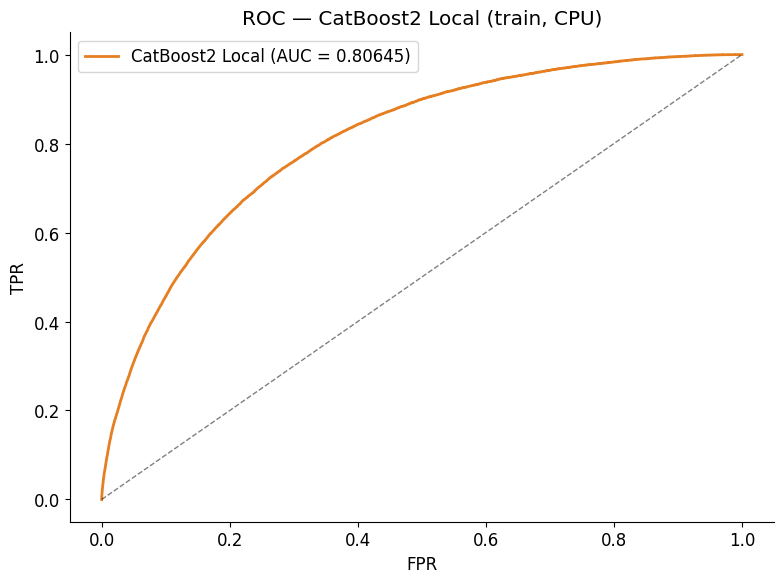

02:24:35 │ roc_curve.png guardado.


In [12]:
fpr, tpr, _ = roc_curve(y, y_prob_train)
auc_val      = roc_auc_score(y, y_prob_train)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#e67e22', lw=2, label=f'CatBoost2 Local (AUC = {auc_val:.5f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — CatBoost2 Local (train, CPU)')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120)
plt.show()
log('roc_curve.png guardado.')

## 4. Importancia de Variables

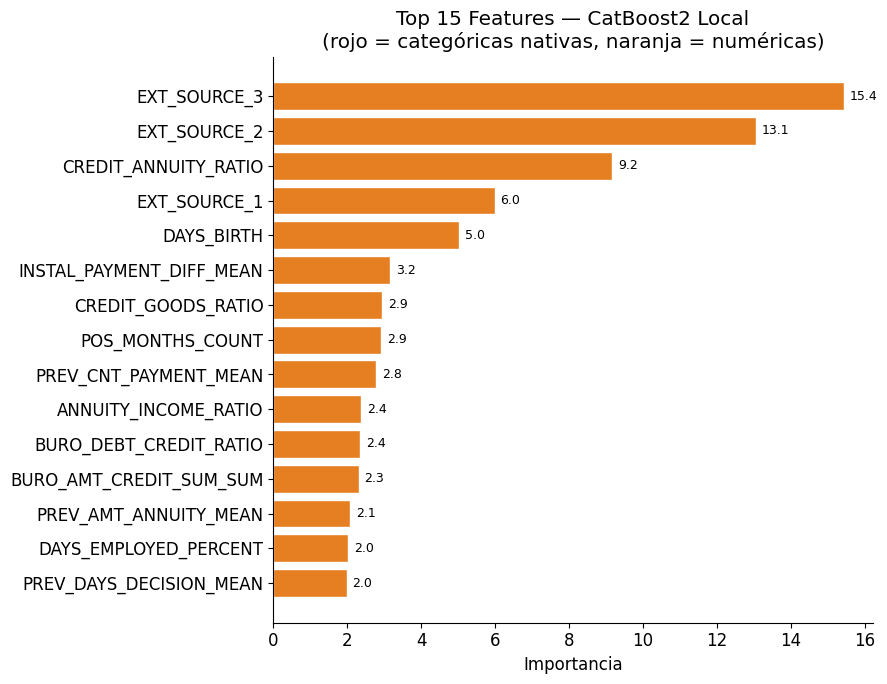

02:24:35 │ feature_importance.png guardado.


,feature,importance,is_cat
0,EXT_SOURCE_3,15.444091,False
1,EXT_SOURCE_2,13.050640,False
2,CREDIT_ANNUITY_RATIO,9.169111,False
3,EXT_SOURCE_1,5.992681,False
4,DAYS_BIRTH,5.025962,False
5,INSTAL_PAYMENT_DIFF_MEAN,3.162160,False
6,CREDIT_GOODS_RATIO,2.948963,False
7,POS_MONTHS_COUNT,2.915739,False
8,PREV_CNT_PAYMENT_MEAN,2.783401,False
9,ANNUITY_INCOME_RATIO,2.383460,False


In [13]:
importance  = model.get_feature_importance()
feat_imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importance})
feat_imp_df['is_cat'] = feat_imp_df['feature'].isin(cat_cols)
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False)

top15 = feat_imp_df.head(15)
colors = ['#c0392b' if is_cat else '#e67e22' for is_cat in top15['is_cat'][::-1]]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top15['feature'][::-1], top15['importance'][::-1],
               color=colors, edgecolor='white')
ax.set_xlabel('Importancia')
ax.set_title('Top 15 Features — CatBoost2 Local\n(rojo = categóricas nativas, naranja = numéricas)')
for bar, val in zip(bars, top15['importance'][::-1]):
    ax.text(bar.get_width() + top15['importance'].max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()
log('feature_importance.png guardado.')
display(feat_imp_df.reset_index(drop=True))

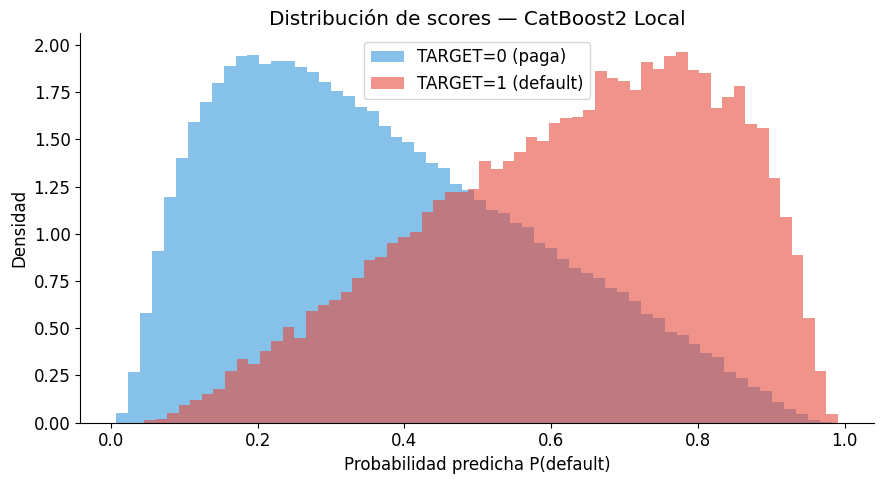

02:24:36 │ score_distribution.png guardado.


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(y_prob_train[y == 0], bins=60, alpha=0.6, color='#3498db',
        label='TARGET=0 (paga)', density=True)
ax.hist(y_prob_train[y == 1], bins=60, alpha=0.6, color='#e74c3c',
        label='TARGET=1 (default)', density=True)
ax.set_xlabel('Probabilidad predicha P(default)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de scores — CatBoost2 Local')
ax.legend()
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=120)
plt.show()
log('score_distribution.png guardado.')

## 5. Guardar Modelo y Metadata

In [16]:
model_path = MODEL_DIR / 'catboost2_local_best.cbm'
model.save_model(str(model_path))

metadata = {
    'best_params'      : {k: float(v) if isinstance(v, (int, float)) else v
                          for k, v in study.best_params.items()},
    'best_n_rounds'    : int(best_n_iter),
    'best_n_iter'      : int(best_n_iter),
    'best_cv_auc'      : float(study.best_trial.user_attrs['cv_auc']),
    'best_obj_auc'     : float(study.best_value),
    'train_auc'        : float(metrics['AUC']),
    'feature_cols'     : list(feature_cols),
    'cat_cols'         : list(cat_cols),
    'cat_features_idx' : list(cat_features_idx),
    'n_trials'         : N_TRIALS,
    'n_folds'          : N_FOLDS,
    'method'           : 'cv',
    'early_stop'       : EARLY_STOP,
    'use_gpu'          : False,
    'catboost_version' : catboost.__version__,
    'timestamp'        : pd.Timestamp.now().isoformat()
}

meta_path = 'catboost2_local_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

log('=' * 65)
log('ARTEFACTOS GUARDADOS')
log('=' * 65)
log(f'  optuna_trials.csv')
log(f'  catboost2_local_train.log')
log('=' * 65)

02:29:55 │ =================================================================
02:29:55 │ ARTEFACTOS GUARDADOS
02:29:55 │ =================================================================
02:29:55 │   optuna_trials.csv
02:29:55 │   catboost2_local_train.log
02:29:55 │ =================================================================


## Resumen Final

In [17]:
log('=' * 65)
log('CATBOOST2 LOCAL — RESUMEN')
log('=' * 65)
log('Mejoras respecto a CatBoost v1:')
log('  - Evaluación: 5-fold CV (comparable con XGBoost y LightGBM)')
log(f'  - Variables categóricas nativas: {cat_cols}')
log('  - Bootstrap MVS habilitado (CPU only)')
log('')
log('Hiperparámetros óptimos (Optuna):')
for k, v in study.best_params.items():
    log(f'  {k:<24}: {v}')
log(f'  {"n_iterations":<24}: {best_n_iter}  (via early stopping en CV)')
log('')
log('Métricas:')
log(f'  Train AUC       : {metrics["AUC"]}')
log(f'  CV AUC (5-fold) : {metrics["CV_AUC"]}')
log(f'  Gap Train - CV  : {metrics["AUC"] - metrics["CV_AUC"]:.5f}')
log(f'  Recall          : {metrics["Recall"]}')
log(f'  Precision       : {metrics["Precision"]}')
log(f'  F1              : {metrics["F1"]}')
log('')
log('Entorno:')
log(f'  CatBoost version: {catboost.__version__}')
log(f'  GPU usado       : False  (CPU mode)')
log(f'  Timestamp       : {metadata["timestamp"]}')
log(f'  Log guardado en : {LOG_PATH.resolve()}')
log('=' * 65)

02:29:58 │ =================================================================
02:29:58 │ CATBOOST2 LOCAL — RESUMEN
02:29:58 │ =================================================================
02:29:58 │ Mejoras respecto a CatBoost v1:
02:29:58 │   - Evaluación: 5-fold CV (comparable con XGBoost y LightGBM)
02:29:58 │   - Variables categóricas nativas: ['NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
02:29:58 │   - Bootstrap MVS habilitado (CPU only)
02:29:58 │ 
02:29:58 │ Hiperparámetros óptimos (Optuna):
02:29:58 │   bootstrap_type          : Bayesian
02:29:58 │   learning_rate           : 0.07982728421004769
02:29:58 │   depth                   : 4
02:29:58 │   l2_leaf_reg             : 29.574174972764606
02:29:58 │   random_strength         : 9.148016630008561
02:29:58 │   bagging_temperature     : 0.1575796408951975
02:29:58 │   n_iterations            : 993  (via early stopping en CV)
02:29:58 │ 
02:29:5